---
# Metody probabilistyczne
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score, confusion_matrix

In [2]:
sklearn.set_config(transform_output="pandas")
sklearn.__version__

'1.7.1'

# Przykład - [SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection)

Tym razem zajmiemy się analizą danych tekstowych na przykładzie filtra spamu

## Załadowanie danych

In [3]:
sms = pd.read_csv('SMSSpamCollection', delimiter='\t', header=None, names=['is_spam', 'text'])

### Kategorie
Czy na pewno są tylko dwie? Jaki jest ich rozkład?

In [4]:
sms['is_spam'].value_counts()

is_spam
ham     4825
spam     747
Name: count, dtype: int64

Podmieniamy klasy na binarne, ale traktując `spam` jako pozytywną

In [5]:
sms.loc[sms['is_spam'] == 'spam', 'is_spam'] = 1
sms.loc[sms['is_spam'] == 'ham', 'is_spam']  = 0
# Obowiązkowo, zamieniamy typ na int
sms['is_spam']=  sms['is_spam'].astype('int8')

## Wstępna analiza danych (EDA, *explanatory data analysis*)

Rzut oka na podstawowe statystyki dotyczące danych wejściowych może być pomocne w dostosowaniu modelu i hiperparametrów.

### Rozkład długości tekstu dla każdej z kategorii

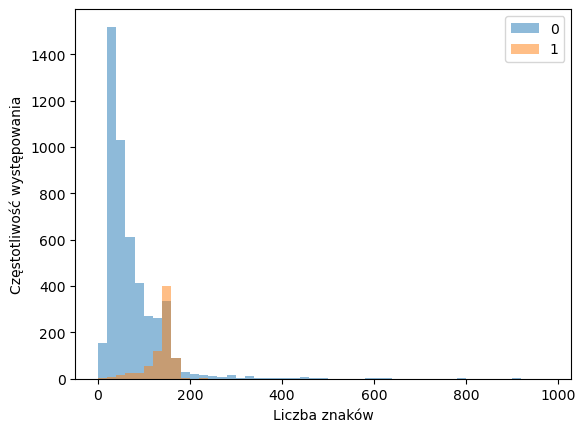

In [6]:
for cat in sms['is_spam'].unique():
    sms[sms['is_spam'] == cat]['text'].str.len().plot(bins=np.arange(0, 1000, 20), 
                                                      kind='hist', label=cat, alpha=0.5)
plt.xlabel('Liczba znaków')
plt.ylabel('Częstotliwość występowania')
# plt.yscale('log')
plt.legend();

Widać, że rozkłady długości dla obu kategorii są bardzo różne, ale nie możemy użyć tej statystyki do dobrego rozgraniczenia cech (chyba że intersuje nas wstępna filtracja danych).

## Wstępne przetwarzanie danych

### Podział na zbiór treningowy i testowy

Wyjątkowo robimy to teraz (por. poprzednie ćwiczenia), bo transformacja zależy od zbioru treningowego

In [7]:
X = sms['text']
y = sms['is_spam']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    test_size=0.2, random_state=0)

### Transformacja (wektoryzacja)

- Użyjemy wektoryzacji zliczeniowej (*count vectorization*)
- Wektoryzacja ta polega na skonstruowaniu macierzy zliczeń tokenów w tekście, co transformuje tekst w dane kategoryczne
- Poniżej używamy domyślnych parametrów oprócz usuwania mało isotnych słów (*stop words*) z języka angielskiego

In [9]:
vect = CountVectorizer(stop_words='english')

In [10]:
vect.fit(X_train)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [11]:
X_train_scaled     = vect.transform(X_train)
X_test_scaled      = vect.transform(X_test)
X_train_scaled_inv = vect.inverse_transform(X_train_scaled)
X_test_scaled_inv  = vect.inverse_transform(X_test_scaled)

#### Przykład

Zobaczmy, jak ta wektoryzacja działa w praktyce

In [12]:
idx = 100

Tekst orginalny

In [13]:
X_train.iloc[idx]

'Night night, see you tomorrow'

Tekst zakodowany 
- domyślnie to macierz rzadka
- poniżej wyświetlamy wartości na niezerowych pozycjach

In [14]:
nonzero_args = np.nonzero(X_train_scaled[idx].todense())
X_train_scaled[idx].todense()[nonzero_args]

matrix([[2, 1]])

Tekst odkodowany

In [15]:
X_train_scaled_inv[idx]

array(['night', 'tomorrow'], dtype='<U34')

## Naiwny klasyfikator Bayesa

Jako *baseline* użyjemy naiwnego klasyfikatora Bayesa z wielomianowym modelowaniem wiarygodności (*likelihood*), który jest zalecany do macierzy zliczeń

In [16]:
nbc = MultinomialNB()

### Dostrajamy model

In [17]:
nbc.fit(X_train_scaled, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### Sprawdzamy wyniki

In [18]:
y_train_pred = nbc.predict(X_train_scaled)
y_test_pred = nbc.predict(X_test_scaled)

In [19]:
roc_auc_score(y_train, y_train_pred), roc_auc_score(y_test, y_test_pred)

(0.9914970953536926, 0.9382946350410606)

In [20]:
confusion_matrix(y_train, y_train_pred)

array([[3845,   14],
       [   8,  590]])

In [21]:
confusion_matrix(y_test, y_test_pred)

array([[957,   9],
       [ 17, 132]])

Istotnie, wyniki są bardzo obiecujące!